In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.integrate import dblquad
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Constants
w_0 = 5
n_0 = 1.000277
z_w = 50
alpha = 0.002
dndT = -7.7*10**(-4) / 770 * 0.002
gamma = 0.5
n = n_0
xi = 1
###
rho = 1.225 
c_rho = 1005  
kappa = 0.025  
alpha_loss = 0.01 

# Initial conditions
C_0 = 100
W_x_0 = W_y_0 = (w_0 * np.sqrt(n_0 * alpha)) / (np.sqrt(w_0**4 + (0-z_w)**2))
T_x_0 = T_y_0 = 0
X_0 = Y_0 = 0
F_x_0 = F_y_0 = (-0.5 * n_0 * alpha * (0-z_w)) / (w_0**4 + (0-z_w)**2)
P_0 = np.arctan(z_w / w_0**2)

# Define the (x, y) grid globally
x_cor = np.linspace(-10, 10, 10)
y_cor = np.linspace(-10, 10, 10)
x_grid, y_grid = np.meshgrid(x_cor, y_cor)

def heat_profile(system):
    C, W_x, W_y, T_x, T_y_0, X, Y, F_x, F_y, P = system
    T = np.zeros_like(x_grid)
    for i in range(10):
        for j in range(10):
            T[i, j] = solve_heat_equation(x_grid[i, j], y_grid[i, j], X, Y, W_x, W_y)
    return -dndT * T


def solve_heat_equation(x, y, X, Y, W_x, W_y):
    f = lambda x_prime, y_prime: (1/2 * np.log((x - x_prime)**2 + (y - y_prime)**2))
    g = lambda x_prime, y_prime: (np.exp(-W_x**2 * (x_prime - X)**2) * np.exp(-W_y**2 * (y_prime - Y)**2))
    integrand = lambda x_prime, y_prime: f(x_prime, y_prime) * g(x_prime, y_prime)
    result, _ = dblquad(integrand, X-1, X+1, Y-1, Y+1)
    return result

def transverse_integral(turb_grid, mode_function, x_grid, y_grid, upsilon):
    vectorized_mode_function = np.vectorize(mode_function)
    mode_grid = vectorized_mode_function(x_grid, y_grid)
    product = turb_grid * mode_grid
    dx = (x_cor[1] - x_cor[0])
    dy = (y_cor[1] - y_cor[0])
    return np.sum(product) * dx * dy * upsilon

def beam_system(z, y, delta_n_thermal, upsilon):
    C, W_x, W_y, T_x, T_y, X, Y, F_x, F_y, P = y
    return [
        0,
        (2 / (n * xi)) * F_x * W_x,
        (2 / (n * xi)) * F_y * W_y,
        -n * gamma**2 * transverse_integral(delta_n_thermal, lambda x, y: 4 * W_x**2 * (x - X) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        -n * gamma**2 * transverse_integral(delta_n_thermal, lambda x, y: 4 * W_y**2 * (y - Y) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        -2 * T_x,
        -2 * T_y,
        (-W_x**4 / (2 * n * xi)) + (2 * F_x**2 / (n * xi)) + (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: W_x**2 * (1 - 2 * W_x**2 * (x - X)) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        (-W_y**4 / (2 * n * xi)) + (2 * F_y**2 / (n * xi)) + (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: W_y**2 * (1 - 2 * W_y**2 * (y - Y)) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        ((W_x**2 + W_y**2) / (2 * n * xi)) - (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: (2 - W_x**2 * (x - X)**2 - W_y**2 * (y - Y)**2) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon)
    ]


# Initialize the state vector y for the first iteration
y = np.array([C_0, W_x_0, W_y_0, T_x_0, T_y_0, X_0, Y_0, F_x_0, F_y_0, P_0])
z_range = (0, 10000)

# Store each iteration's results
optical_results = []
thermal_results = []

# Initialize the state vector for the simulation
y = np.array([C_0, W_x_0, W_y_0, T_x_0, T_y_0, X_0, Y_0, F_x_0, F_y_0, P_0])
z_range = (0, 10000)

num_iterations = 25
for i in range(num_iterations):  # Run the simulation for 10 iterations
    delta_n_thermal = heat_profile(y)
    thermal_results.append(delta_n_thermal)  # Store the thermal profile for each iteration
    
    upsilon = (1 / (2 * np.pi)) * (1 / kappa) * ((alpha / (rho * c_rho)) * y[0]**2 * (y[1] * y[2]) / np.pi * np.exp(-alpha_loss * z_w))
    sol = solve_ivp(lambda z, y: beam_system(z, y, delta_n_thermal, upsilon), z_range, y, method='RK45', t_eval=np.linspace(z_range[0], z_range[1], 100))
    
    optical_results.append(sol.y)  # Ensure only sol.y is stored
    y = sol.y[:, -1]  # Update the state vector with the final values from the last timestep



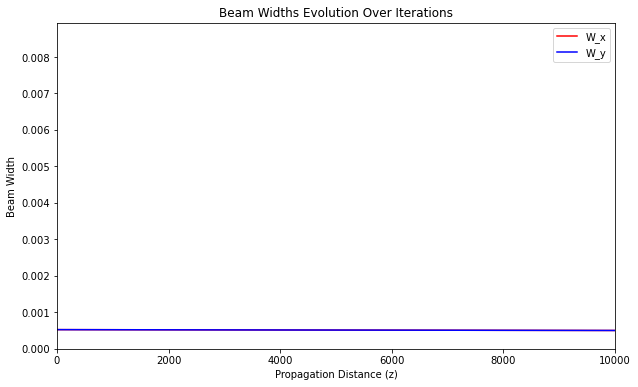

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create figure for the Beam Widths animation
fig_widths, ax_widths = plt.subplots(figsize=(10, 6))
ax_widths.set_title('Beam Widths Evolution Over Iterations')
ax_widths.set_xlabel('Propagation Distance (z)')
ax_widths.set_ylabel('Beam Width')
ax_widths.set_xlim(z_range[0], z_range[1])
ax_widths.set_ylim(0, max([np.max(data[1, :]) for data in optical_results] + [np.max(data[2, :]) for data in optical_results]))

line1, = ax_widths.plot([], [], 'r-', label='W_x')
line2, = ax_widths.plot([], [], 'b-', label='W_y')
ax_widths.legend()

# Initialization and animation functions
def init_widths():
    line1.set_data([], [])
    line2.set_data([], [])
    return line1, line2,

def animate_widths(i):
    z_values = np.linspace(z_range[0], z_range[1], 100)
    W_x_values = optical_results[i][1, :]
    W_y_values = optical_results[i][2, :]
    line1.set_data(z_values, W_x_values)
    line2.set_data(z_values, W_y_values)
    return line1, line2,

# Create and display the animation for Beam Widths
ani_widths = FuncAnimation(fig_widths, animate_widths, init_func=init_widths, frames=len(optical_results), interval=150, blit=True)
HTML(ani_widths.to_jshtml())


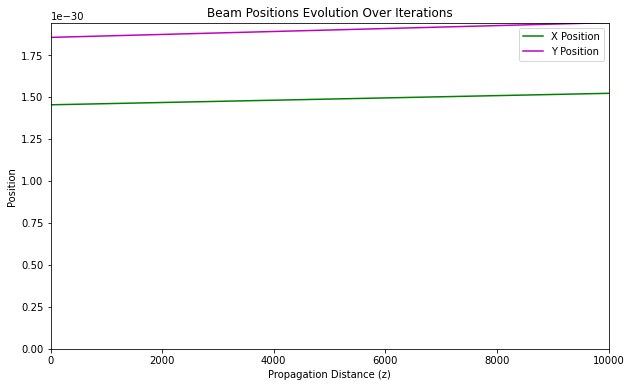

In [21]:
# Create figure for the Beam Positions animation
fig_positions, ax_positions = plt.subplots(figsize=(10, 6))
ax_positions.set_title('Beam Positions Evolution Over Iterations')
ax_positions.set_xlabel('Propagation Distance (z)')
ax_positions.set_ylabel('Position')
ax_positions.set_xlim(z_range[0], z_range[1])
ax_positions.set_ylim(min([np.min(data[5, :]) for data in optical_results] + [np.min(data[6, :]) for data in optical_results]), max([np.max(data[5, :]) for data in optical_results] + [np.max(data[6, :]) for data in optical_results]))

line3, = ax_positions.plot([], [], 'g-', label='X Position')
line4, = ax_positions.plot([], [], 'm-', label='Y Position')
ax_positions.legend()

# Initialization and animation functions
def init_positions():
    line3.set_data([], [])
    line4.set_data([], [])
    return line3, line4,

def animate_positions(i):
    z_values = np.linspace(z_range[0], z_range[1], 100)
    X_values = optical_results[i][5, :]
    Y_values = optical_results[i][6, :]
    line3.set_data(z_values, X_values)
    line4.set_data(z_values, Y_values)
    return line3, line4,

# Create and display the animation for Beam Positions
ani_positions = FuncAnimation(fig_positions, animate_positions, init_func=init_positions, frames=len(optical_results), interval=150, blit=True)
HTML(ani_positions.to_jshtml())


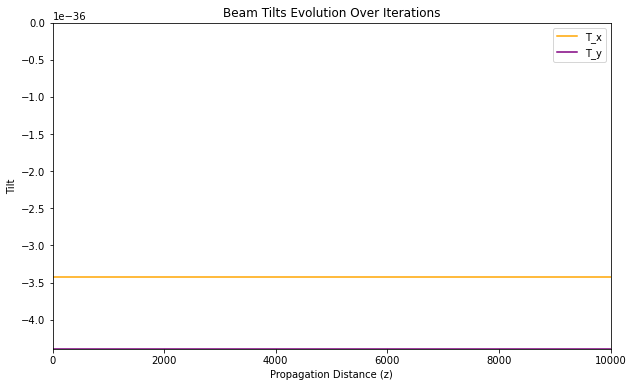

In [22]:
# Create figure for Beam Tilts animation
fig_tilts, ax_tilts = plt.subplots(figsize=(10, 6))
ax_tilts.set_title('Beam Tilts Evolution Over Iterations')
ax_tilts.set_xlabel('Propagation Distance (z)')
ax_tilts.set_ylabel('Tilt')
ax_tilts.set_xlim(z_range[0], z_range[1])
ax_tilts.set_ylim(min([np.min(data[3, :]) for data in optical_results] + [np.min(data[4, :]) for data in optical_results]), max([np.max(data[3, :]) for data in optical_results] + [np.max(data[4, :]) for data in optical_results]))

line5, = ax_tilts.plot([], [], 'orange', label='T_x')
line6, = ax_tilts.plot([], [], 'purple', label='T_y')
ax_tilts.legend()

def init_tilts():
    line5.set_data([], [])
    line6.set_data([], [])
    return line5, line6,

def animate_tilts(i):
    z_values = np.linspace(z_range[0], z_range[1], 100)
    T_x_values = optical_results[i][3, :]
    T_y_values = optical_results[i][4, :]
    line5.set_data(z_values, T_x_values)
    line6.set_data(z_values, T_y_values)
    return line5, line6,

ani_tilts = FuncAnimation(fig_tilts, animate_tilts, init_func=init_tilts, frames=len(optical_results), interval=150, blit=True)
HTML(ani_tilts.to_jshtml())


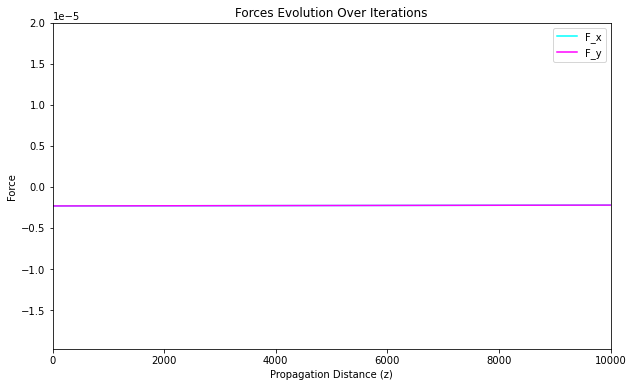

In [23]:
# Create figure for Forces animation
fig_forces, ax_forces = plt.subplots(figsize=(10, 6))
ax_forces.set_title('Forces Evolution Over Iterations')
ax_forces.set_xlabel('Propagation Distance (z)')
ax_forces.set_ylabel('Force')
ax_forces.set_xlim(z_range[0], z_range[1])
ax_forces.set_ylim(min([np.min(data[7, :]) for data in optical_results] + [np.min(data[8, :]) for data in optical_results]), max([np.max(data[7, :]) for data in optical_results] + [np.max(data[8, :]) for data in optical_results]))

line7, = ax_forces.plot([], [], 'cyan', label='F_x')
line8, = ax_forces.plot([], [], 'magenta', label='F_y')
ax_forces.legend()

def init_forces():
    line7.set_data([], [])
    line8.set_data([], [])
    return line7, line8,

def animate_forces(i):
    z_values = np.linspace(z_range[0], z_range[1], 100)
    F_x_values = optical_results[i][7, :]
    F_y_values = optical_results[i][8, :]
    line7.set_data(z_values, F_x_values)
    line8.set_data(z_values, F_y_values)
    return line7, line8,

ani_forces = FuncAnimation(fig_forces, animate_forces, init_func=init_forces, frames=len(optical_results), interval=150, blit=True)
HTML(ani_forces.to_jshtml())


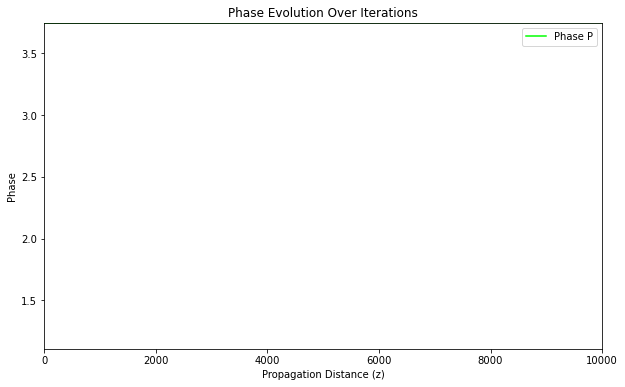

In [24]:
# Create figure for Phase animation
fig_phase, ax_phase = plt.subplots(figsize=(10, 6))
ax_phase.set_title('Phase Evolution Over Iterations')
ax_phase.set_xlabel('Propagation Distance (z)')
ax_phase.set_ylabel('Phase')
ax_phase.set_xlim(z_range[0], z_range[1])
ax_phase.set_ylim(min([np.min(data[9, :]) for data in optical_results]), max([np.max(data[9, :]) for data in optical_results]))

line9, = ax_phase.plot([], [], 'lime', label='Phase P')
ax_phase.legend()

def init_phase():
    line9.set_data([], [])
    return line9,

def animate_phase(i):
    z_values = np.linspace(z_range[0], z_range[1], 100)
    P_values = optical_results[i][9, :]
    line9.set_data(z_values, P_values)
    return line9,

ani_phase = FuncAnimation(fig_phase, animate_phase, init_func=init_phase, frames=len(optical_results), interval=150, blit=True)
HTML(ani_phase.to_jshtml())


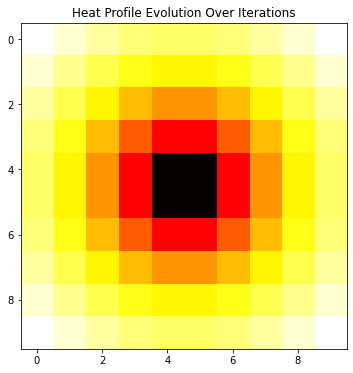

In [25]:
# Heat profile animation using the last axis
fig_heat, ax_heat = plt.subplots(figsize=(8, 6))
ax_heat.set_title('Heat Profile Evolution Over Iterations')
def animate_heat(i):
    ax_heat.imshow(thermal_results[i], cmap='hot', interpolation='nearest')
    return ax_heat,

ani_heat = FuncAnimation(fig_heat, animate_heat, frames=len(thermal_results), interval=150)
HTML(ani_heat.to_jshtml())
